# ToBigs 정규세션 5주차 XAI 과제 _ 25기 이유민


# 1. Lime

In [1]:
!pip install lime

     ---------------------------------------- 0.0/275.7 kB ? eta -:--:--
     -------------------------------------- 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283842 sha256=eaee3dbb4d61bf29aa4c856a36411465f1938018fb4ef65494411a2c706ad77b
  Stored in directory: c:\users\yoomi\appdata\local\pip\cache\wheels\e7\5d\0e\4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [3]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=data.feature_names,
    class_names=data.target_names,
    mode='classification'
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=rf_model.predict_proba,
    num_features=5 # 상위 5개 주요 feature만
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

C:\Users\yoomi\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\yoomi\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\yoomi\anaconda3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답: LIME은 먼저 설명하고자 하는 원본 데이터 포인트를 선택한 뒤, 해당 데이터의 특징에 약간의 노이즈나 변형을 가하여 주변에 수많은 가상의 데이터 샘플들을 무작위로 생성하는 것으로 시작합니다. 그런 다음 이렇게 생성된 가상 샘플들을 기존의 블랙박스 모델에 통과시켜 각각의 예측값을 구하고, 원본 데이터와의 거리를 계산하여 원본과 가까운 샘플일수록 더 높은 가중치를 부여합니다. 마지막으로, 가중치가 반영된 샘플 데이터와 예측값들을 사용하여 선형 회귀나 의사결정 나무처럼 사람이 직관적으로 해석할 수 있는 단순한 대리 모델을 학습시킵니다. 결과적으로 이 단순화된 국소 모델의 가중치를 분석함으로써, 원본 데이터의 어떤 특징들이 블랙박스 모델의 해당 예측에 가장 큰 영향을 미쳤는지 직관적으로 파악할 수 있게 됩니다.

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답: LIME에서 대리 모델(Surrogate Model)은 복잡하고 해석하기 어려운 원본 블랙박스 모델의 동작을 특정 데이터 포인트 주변에서 그대로 모방하도록 학습된 단순한 모델입니다. 인공신경망이나 앙상블 모델처럼 내부 구조가 복잡한 모델 전체를 파악하는 것은 불가능에 가깝지만, 특정 예측 근처의 데이터들만 떼어내어 선형 회귀나 의사결정 나무 같은 직관적인 대리 모델을 학습시키면, 그 대리 모델이 가진 가중치나 판단 규칙을 통해 원본 모델의 의사결정 근거를 쉽게 역추적할 수 있습니다.

---

#2. SHAP

In [5]:
!pip install shap

     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ---------------------------------------- 60.9/60.9 kB 3.2 MB/s eta 0:00:00
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.2 which is incompatible.


### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


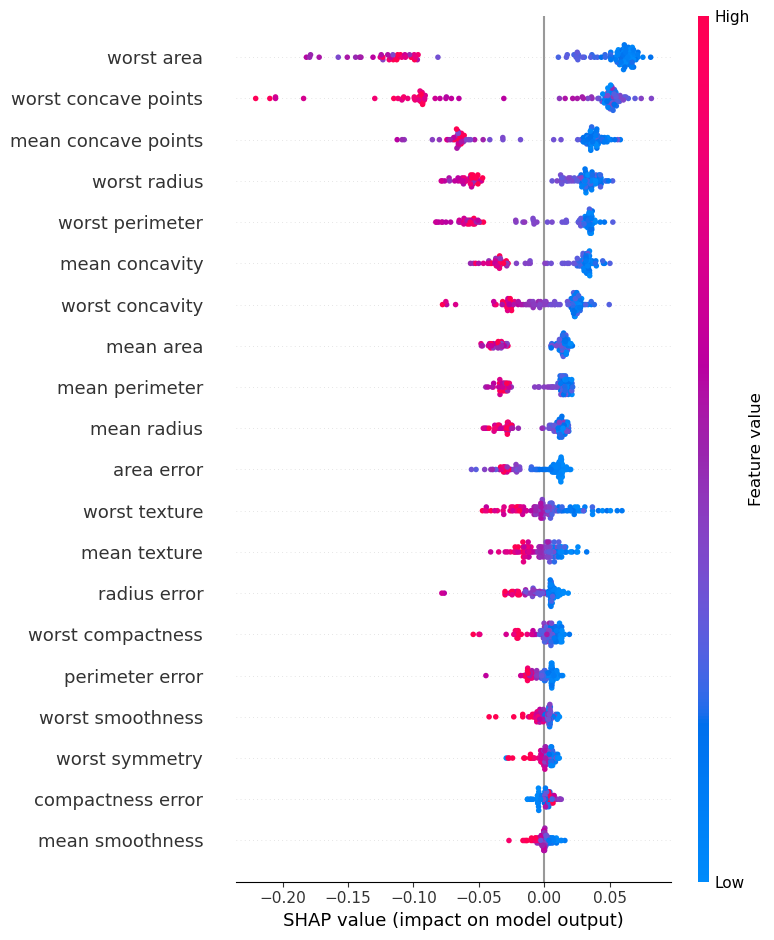

In [6]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)

# 결과 시각화 준비
if isinstance(shap_values, list):

    target_shap_values = shap_values[1]
    base_value = explainer_shap.expected_value[1]
else:
    if len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3. SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답: SHAP Value가 양수인 특성은 모델의 최종 예측값을 평균보다 더 높이는 방향으로 기여했음을 의미합니다. 반대로 SHAP Value가 음수인 특성은 모델의 최종 예측값을 평균보다 더 낮추는 방향으로 기여했음을 뜻합니다.

Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답: 기존 트리 기반 모델의 중요도는 트리가 학습되는 과정에서 특정 특성이 노드를 분기할 때 데이터의 불순도를 평균적으로 얼마나 감소시켰는지를 측정합니다. 이는 모델 전체의 관점에서 어떤 특성이 데이터 분할에 유용하게 쓰였는지를 보여주는 전역적 설명에 국한됩니다. 예측값을 구체적으로 높였는지 낮췄는지에 대한 방향성을 알 수 없으며, 고유값이 많은 변수나 연속형 변수에 중요도가 과대하게 부여되는 편향(Bias) 문제가 존재합니다. 그에 반해, SHAP의 특성 중요도는 각 특성이 모델의 최종 예측값 도출에 기여한 한계 기여도를 수학적으로 계산한 값입니다. 이는 특정 데이터 하나하나의 예측 결과를 설명하는 국소적 설명이 가능하고, 예측값을 증가시켰는지 감소시켰는지에 대한 명확한 방향성을 제공합니다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

In [9]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/40.2 MB 15.0 MB/s eta 0:00:03
   - -------------------------------------- 1.1/40.2 MB 13.5 MB/s eta 0:00:03
   - -------------------------------------- 1.6/40.2 MB 12.6 MB/s eta 0:00:04
   -- ------------------------------------- 2.2/40.2 MB 12.4 MB/s eta 0:00:04
   -- ------------------------------------- 2.7/40.2 MB 12.2 MB/s eta 0:00:04
   --- ------------------------------------ 3.2/40.2 MB 12.0 MB/s eta 0:00:04
   --- ------------------------------------ 3.7/40.2 MB 11.9 MB/s eta 0:00:04
   ---- ----------------------------------- 4.3/40.2 MB 11.9 MB/s eta 0:00:04
   ---- ----------------------------------- 4.8/40.2 MB 11.7 MB/s eta 0:00:04
   ----- ---------------------------------- 5.3/40.2 MB 11.8 MB/s eta 0:00:03
   ----- ---------------------------------- 5.8/40.2 MB 11.7 MB/s eta 0:00:03
   ------ --------------------------------- 6.4/40.2 MB 11.7 MB/s eta 0:

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\yoomi/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:48<00:00, 11.4MB/s] 


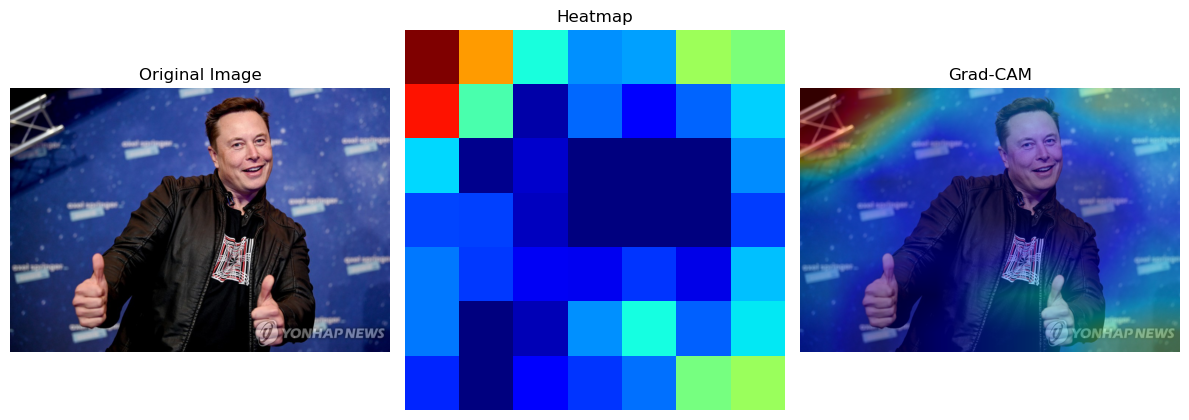

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()

# 그래디언트와 특성 맵을 저장할 변수
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item()

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward()

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

# 특성 맵과 가중치 결합
heatmap = torch.sum(weights * activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본과 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답: Grad-CAM에서 마지막 컨볼루션 층을 사용하는 이유는 해당 층이 이미지의 핵심적인 '의미 정보(What)'와 2차원의 '공간 정보(Where)'를 동시에 보존하고 있는 최적의 지점이기 때문입니다. 이 층은 신경망의 가장 깊은 곳에 위치하여 모델 예측에 필요한 고수준의 복잡한 특징을 모두 파악한 상태이면서도, 데이터가 완전 연결 층(FC Layer)으로 넘어가 1차원으로 평탄화되며 위치 좌표가 소실되기 직전의 단계입니다. 따라서 모델이 판단의 근거로 삼은 주요 특징이 원본 이미지 상의 어느 위치에 존재하는지 히트맵으로 시각화하기 위해 이 마지막 층의 정보를 활용합니다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답: Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델이 특정 클래스로 최종 예측을 내리는 데 있어 가장 결정적이고 긍정적인 영향을 미친 핵심 영역을 의미합니다. 즉, 모델이 해당 예측을 수행할 때 이미지 내에서 가장 집중해서 바라본 중요한 판단 근거 지점임을 시각적으로 나타내는 것입니다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: Grad-CAM으로 시각화한 히트맵이 항상 이미지 내의 실제 중요한 객체를 정확히 담고 있는 것은 아닙니다.
그 이유는 Grad-CAM이 '사람이 인지하는 중요한 객체'가 아니라 철저히 '모델이 정답을 맞히기 위해 실제로 의존한 판단 근거'만을 보여주기 때문입니다. 만약 모델이 학습 데이터의 편향성으로 인해 객체 자체가 아닌 주변 환경을 판단 근거로 잘못 학습했다면, 히트맵은 객체가 아닌 배경을 붉게 강조하게 됩니다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

In [12]:
# 이미지 로드 및 전처리
img = Image.open('tobigi.png').convert('RGB')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0)

In [13]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

config.json: 0.00B [00:00, ?B/s]

C:\Users\yoomi\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yoomi\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [14]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [15]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [16]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [17]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

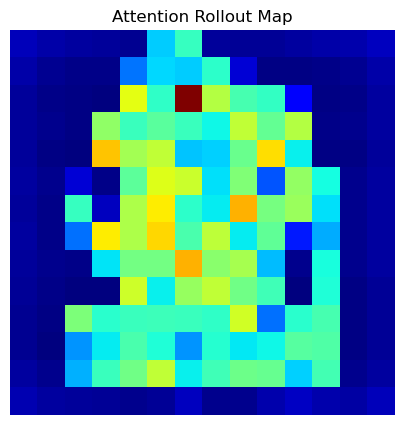

In [18]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



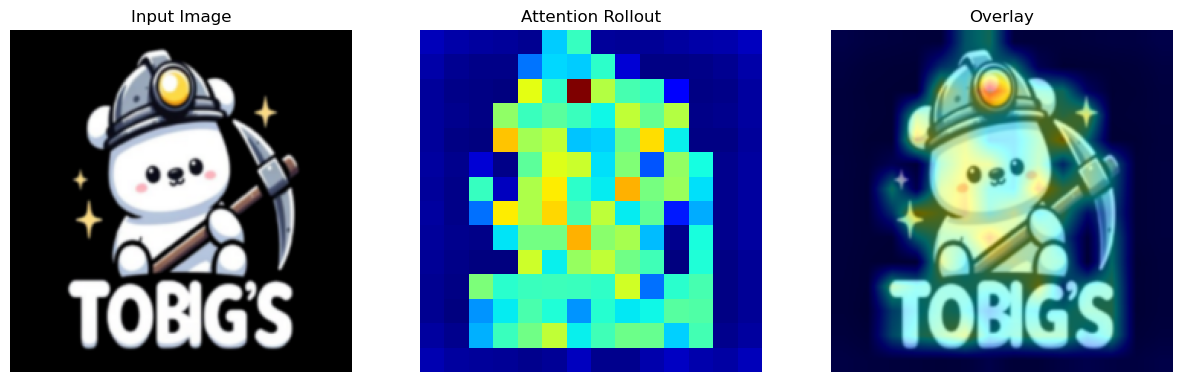

In [19]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: 기존의 Attention Score 방식은 주로 특정 단일 층의 점수만 확인하므로, 트랜스포머 모델이 여러 층을 거치며 정보를 지속적으로 섞는 '정보 혼합' 현상과 어텐션 연산을 우회하는 '잔차 연결'의 영향을 제대로 파악하지 못합니다. 반면 Attention Rollout 방식은 잔차 연결을 보정한 뒤 첫 번째 층부터 마지막 층까지의 모든 어텐션 행렬을 순차적으로 곱하여 계산합니다. 이를 통해 최종 예측 결과에서부터 원본 입력 데이터까지 정보가 전달된 전체 흐름을 누적해서 역추적할 수 있으므로, 단순 어텐션 점수보다 원본 데이터의 실제 기여도를 훨씬 더 정확하고 직관적으로 파악할 수 있기 때문에 이 방법을 사용합니다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: 높은 Attention Score를 가진 토큰들을 활용하여 자연어 처리(NLP)를 하게 될 경우, 점수가 높은 단어 토큰들만 선별하여 긴 문서의 핵심 추출 요약이나 키워드를 자동으로 생성하는 시스템을 구축할 수 있으며, 방대한 입력 문맥에서 중요도가 낮은 토큰을 솎아내어 LLM의 메모리 사용량과 처리 비용을 획기적으로 줄이는 프롬프트 압축 기법으로도 발전시킬 수 있을 것입니다.